# Interpretable Phishing URL Detection

**Goal:** classify URLs as phishing or legitimate using a real cybersecurity dataset.

- `0` = phishing URL
- `1` = legitimate URL
- Main model-selection metric: **Macro F1**
- Final test set is touched only after the best model is selected through cross-validation.

**Models:** Logistic Regression, Decision Tree, Random Forest, XGBoost, AdaBoost, HistGradientBoosting.

In [1]:
# Run only if these libraries are not installed
# %pip install -q ucimlrepo xgboost

In [2]:
from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_colwidth", None)

## 1. Load the dataset

In [3]:
phishing = fetch_ucirepo(id=967)

X = phishing.data.features.copy()
y = phishing.data.targets.squeeze().copy()

X.shape, y.shape

((235795, 54), (235795,))

In [4]:
y.value_counts().rename(index={0: "Phishing", 1: "Legitimate"})

label
Legitimate    134850
Phishing      100945
Name: count, dtype: int64

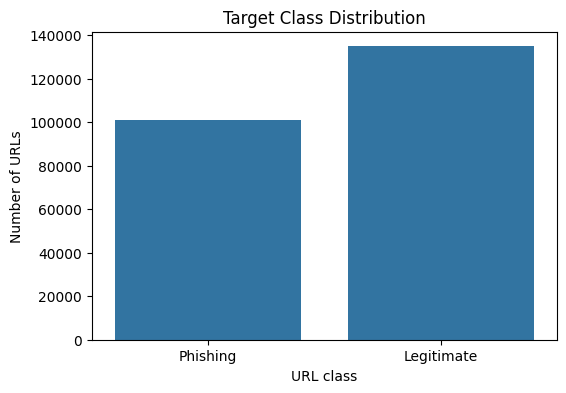

label
Phishing      100945
Legitimate    134850
Name: count, dtype: int64

In [5]:
target_counts = y.value_counts().sort_index().rename(index={0: "Phishing", 1: "Legitimate"})

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.xlabel("URL class")
plt.ylabel("Number of URLs")
plt.title("Target Class Distribution")
plt.show()

target_counts

## 2. Remove raw identifier/text columns

The dataset already contains engineered security features such as URL similarity and TLD legitimacy probability.  
Raw text columns are removed so the models learn from measurable security patterns rather than memorising website text or domains.

In [6]:
columns_to_drop = ["URL", "Domain", "TLD", "Title", "FILENAME"]

X = X.drop(columns=columns_to_drop, errors="ignore")

X.shape, X.select_dtypes(exclude="number").columns.tolist(), X.isna().sum().sum()

((235795, 50), [], 0)

## 3. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.05,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((224005, 50), (11790, 50))

In [8]:
pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
}).rename(index={0: "Phishing", 1: "Legitimate"}).round(3)

,Train,Test
label,,
Phishing,0.428,0.428
Legitimate,0.572,0.572


## 4. Shared preprocessing and search settings

The dataset is large, so we use **3-fold stratified cross-validation** and a compact parameter search.  
`f1_macro` gives phishing and legitimate URLs equal importance during model selection.

In [9]:
scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

search_settings = {
    "scoring": "f1_macro",
    "cv": cv,
    "n_jobs": -1,
    "verbose": 1
}

random_search_settings = {
    **search_settings,
    "n_iter": 10,
    "random_state": 42
}

## 5. Logistic Regression

In [10]:
logistic_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"],
    "model__penalty": ["l2"]
}

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    **search_settings
)

logistic_search.fit(X_train, y_train)

logistic_search.best_params_, logistic_search.best_score_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


({'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'},
 0.999881476456587)

## 6. Decision Tree

In [11]:
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_params = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_params,
    **search_settings
)

tree_search.fit(X_train, y_train)

tree_search.best_params_, tree_search.best_score_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


({'model__criterion': 'gini',
  'model__max_depth': 5,
  'model__min_samples_leaf': 1},
 0.9999908831287952)

## 7. Random Forest

In [12]:
forest_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

forest_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

forest_search = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=forest_params,
    **random_search_settings
)

forest_search.fit(X_train, y_train)

forest_search.best_params_, forest_search.best_score_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


({'model__n_estimators': 100,
  'model__min_samples_split': 5,
  'model__min_samples_leaf': 1,
  'model__max_features': 'sqrt',
  'model__max_depth': 30},
 0.9999863246654245)

## 8. XGBoost

In [14]:
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    **random_search_settings
)

xgb_search.fit(X_train, y_train)

xgb_search.best_params_, xgb_search.best_score_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


({'model__subsample': 0.8,
  'model__n_estimators': 300,
  'model__max_depth': 5,
  'model__learning_rate': 0.03,
  'model__colsample_bytree': 0.8},
 0.9999908831287952)

## 9. AdaBoost

In [15]:
ada_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

ada_params = {
    "model__estimator__max_depth": [1, 2, 3],
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 0.5, 1.0]
}

ada_search = RandomizedSearchCV(
    estimator=ada_pipeline,
    param_distributions=ada_params,
    **random_search_settings
)

ada_search.fit(X_train, y_train)

ada_search.best_params_, ada_search.best_score_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


({'model__n_estimators': 200,
  'model__learning_rate': 1.0,
  'model__estimator__max_depth': 3},
 0.9999908831287952)

## 10. HistGradientBoosting

In [17]:
hist_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

hist_params = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_iter": [100, 200, 300],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__max_depth": [None, 5, 10],
    "model__l2_regularization": [0, 0.1, 1]
}

hist_search = RandomizedSearchCV(
    estimator=hist_pipeline,
    param_distributions=hist_params,
    **random_search_settings
)

hist_search.fit(X_train, y_train)

hist_search.best_params_, hist_search.best_score_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


({'model__max_leaf_nodes': 15,
  'model__max_iter': 300,
  'model__max_depth': 10,
  'model__learning_rate': 0.03,
  'model__l2_regularization': 0},
 0.9999863246654245)

## 11. Compare cross-validation performance

In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "AdaBoost",
        "HistGradientBoosting"
    ],
    "Best CV F1 Macro": [
        logistic_search.best_score_,
        tree_search.best_score_,
        forest_search.best_score_,
        xgb_search.best_score_,
        ada_search.best_score_,
        hist_search.best_score_
    ],
    "CV Standard Deviation": [
        logistic_search.cv_results_["std_test_score"][logistic_search.best_index_],
        tree_search.cv_results_["std_test_score"][tree_search.best_index_],
        forest_search.cv_results_["std_test_score"][forest_search.best_index_],
        xgb_search.cv_results_["std_test_score"][xgb_search.best_index_],
        ada_search.cv_results_["std_test_score"][ada_search.best_index_],
        hist_search.cv_results_["std_test_score"][hist_search.best_index_]
    ],
    "Best Parameters": [
        logistic_search.best_params_,
        tree_search.best_params_,
        forest_search.best_params_,
        xgb_search.best_params_,
        ada_search.best_params_,
        hist_search.best_params_
    ]
}).sort_values("Best CV F1 Macro", ascending=False).reset_index(drop=True)

results

,Model,Best CV F1 Macro,CV Standard Deviation,Best Parameters
0,Decision Tree,0.999991,0.000013,"{'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1}"
1,XGBoost,0.999991,0.000013,"{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}"
2,AdaBoost,0.999991,0.000013,"{'model__n_estimators': 200, 'model__learning_rate': 1.0, 'model__estimator__max_depth': 3}"
3,Random Forest,0.999986,0.000011,"{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}"
4,HistGradientBoosting,0.999986,0.000011,"{'model__max_leaf_nodes': 15, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.03, 'model__l2_regularization': 0}"
5,Logistic Regression,0.999881,0.000042,"{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}"


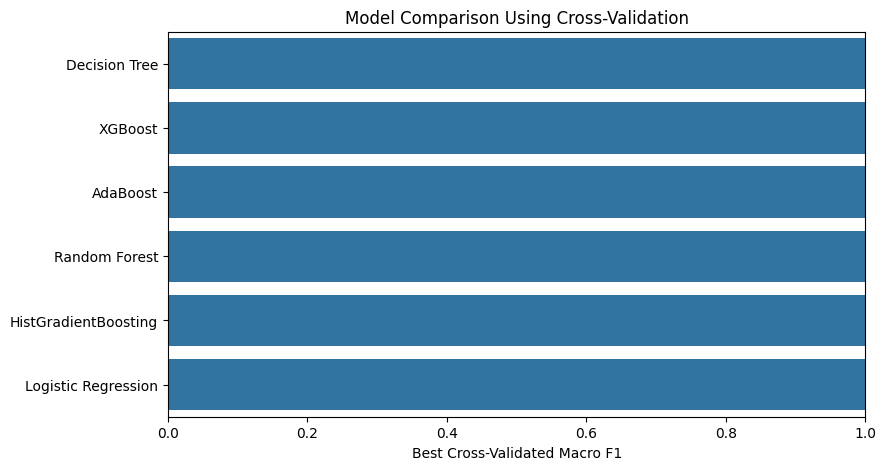

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Best CV F1 Macro",
    y="Model"
)

plt.xlim(0, 1)
plt.xlabel("Best Cross-Validated Macro F1")
plt.ylabel("")
plt.title("Model Comparison Using Cross-Validation")
plt.show()

## 12. Select the winner and evaluate once on the test set

The winning model is selected only from cross-validation results.  
The held-out test set is now used once for final evaluation.

In [20]:
searches = {
    "Logistic Regression": logistic_search,
    "Decision Tree": tree_search,
    "Random Forest": forest_search,
    "XGBoost": xgb_search,
    "AdaBoost": ada_search,
    "HistGradientBoosting": hist_search
}

best_model_name = results.loc[0, "Model"]
best_search = searches[best_model_name]
best_model = best_search.best_estimator_

best_model_name, best_search.best_params_

('Decision Tree',
 {'model__criterion': 'gini',
  'model__max_depth': 5,
  'model__min_samples_leaf': 1})

In [21]:
y_pred = best_model.predict(X_test)

phishing_probability_index = list(best_model.classes_).index(0)
y_phishing_probability = best_model.predict_proba(X_test)[:, phishing_probability_index]
y_test_phishing = (y_test == 0).astype(int)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision - Phishing",
        "Recall - Phishing",
        "F1 - Phishing",
        "F1 Macro",
        "ROC-AUC - Phishing"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, y_pred, average="macro"),
        roc_auc_score(y_test_phishing, y_phishing_probability)
    ]
})

final_metrics.round(4)

,Metric,Score
0,Accuracy,1.0
1,Precision - Phishing,1.0
2,Recall - Phishing,1.0
3,F1 - Phishing,1.0
4,F1 Macro,1.0
5,ROC-AUC - Phishing,1.0


In [22]:
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Phishing", "Legitimate"]
))

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00      5047
  Legitimate       1.00      1.00      1.00      6743

    accuracy                           1.00     11790
   macro avg       1.00      1.00      1.00     11790
weighted avg       1.00      1.00      1.00     11790



## 13. Confusion matrix heatmap

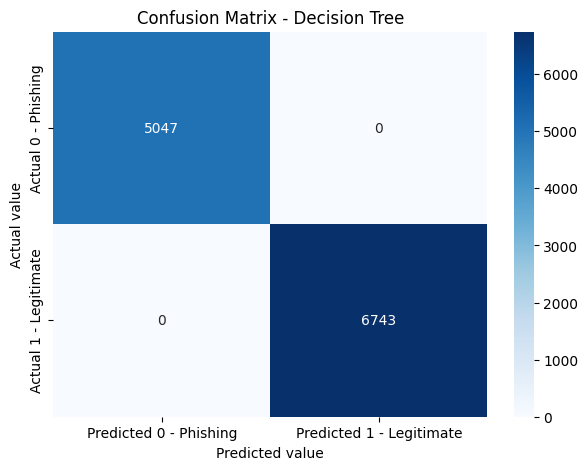

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - Phishing", "Predicted 1 - Legitimate"],
    yticklabels=["Actual 0 - Phishing", "Actual 1 - Legitimate"]
)

plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 14. ROC curve

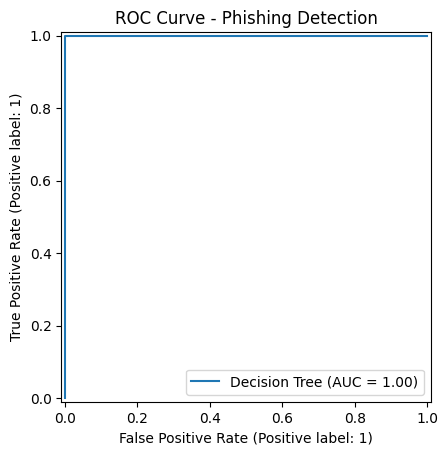

In [24]:
RocCurveDisplay.from_predictions(
    y_test_phishing,
    y_phishing_probability,
    name=best_model_name
)

plt.title("ROC Curve - Phishing Detection")
plt.show()

## 15. Precision–Recall curve

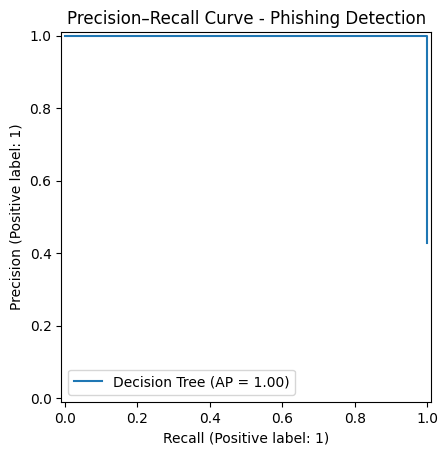

In [25]:
PrecisionRecallDisplay.from_predictions(
    y_test_phishing,
    y_phishing_probability,
    name=best_model_name
)

plt.title("Precision–Recall Curve - Phishing Detection")
plt.show()

## 16. Most influential features of the winning model

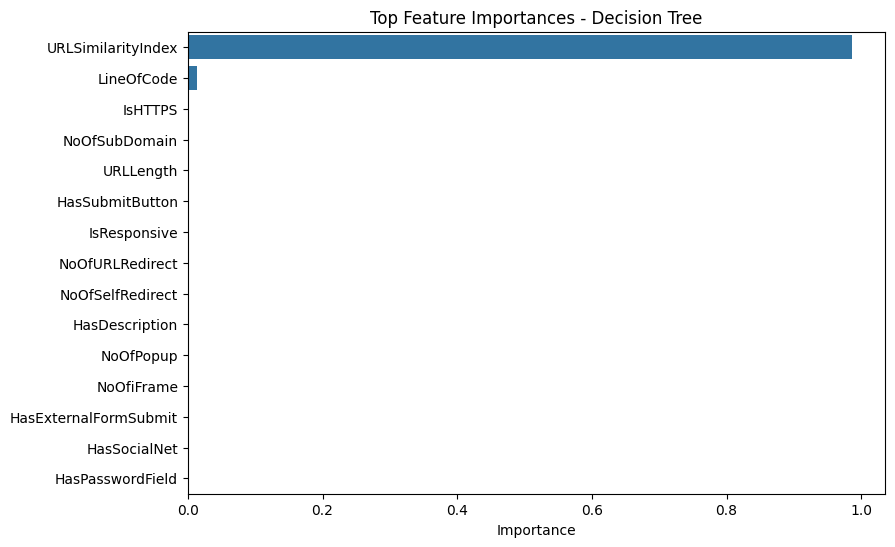

,Feature,Importance
3,URLSimilarityIndex,0.986458
22,LineOfCode,0.013104
21,IsHTTPS,0.000401
8,NoOfSubDomain,0.000036
0,URLLength,0.000000
37,HasSubmitButton,0.000000
29,IsResponsive,0.000000
30,NoOfURLRedirect,0.000000
31,NoOfSelfRedirect,0.000000
32,HasDescription,0.000000


In [26]:
final_estimator = best_model.named_steps["model"]
feature_names = X_train.columns

if hasattr(final_estimator, "feature_importances_"):
    feature_scores = final_estimator.feature_importances_
    importance_title = f"Top Feature Importances - {best_model_name}"
else:
    feature_scores = np.abs(final_estimator.coef_[0])
    importance_title = f"Top Absolute Coefficients - {best_model_name}"

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_scores
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(importance_title)
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

feature_importance

## Project conclusion notes

After running the notebook, complete these points for the portfolio write-up:

- Which model achieved the highest cross-validated Macro F1?
- What was its final test-set Macro F1 and phishing recall?
- How many phishing URLs were missed in the confusion matrix?
- Which features contributed most strongly to prediction?

**Dataset reference:** Prasad, A. & Chandra, S. (2024). *PhiUSIIL Phishing URL (Website)*. UCI Machine Learning Repository.